# Risk preprocess analysis

Load the stage-2 risk CSV and inspect Steam trade, trend, and risk metrics before adding any filters.

## Metrics And Formulas

Stage-1 carry-over:
- `avg_discount = mean(1 - ask / predicted)` on the sampled CSFloat listings
- `median_discount = median(1 - ask / predicted)` on the sampled CSFloat listings
- `n_listings` = observed CSFloat listing count up to preprocess cap
- `base_price` = first non-null CSFloat reference base price in the sample

Steam 7d trade metrics:
- `steam_sales_7d_mean` = mean sale price over Steam `pricehistory` window
- `steam_sales_7d_median` = median sale price over Steam `pricehistory` window
- `steam_sales_7d_p10 / p25 / p75 / p90` = sale-price quantiles over the same 7d window
- `steam_sales_7d_n` = total expanded trade count over the 7d window

Derived Steam risk metrics:
- `steam_sales_7d_iqr_risk% = (p75 - p25) / mean * 100`
- `steam_sales_7d_band_risk% = (p90 - p10) / mean * 100`
- `steam_sales_7d_downside_risk% = (median - p10) / mean * 100`
- `steam_sales_7d_tail_ratio = p10 / median`
- `steam_turnover_proxy = steam_sales_7d_n / n_listings`
- `steam_discount_risk_score = avg_discount - 0.01 * downside_risk + 0.02 * log10(turnover_proxy + 1)`

Daily trend and price-risk metrics use `P_t = daily median Steam sale price`:
- `steam_daily_ret_3d = P_0 / P_-3 - 1`
- `steam_daily_ret_7d = P_0 / P_-7 - 1`
- `steam_daily_slope_7d` = OLS slope of `log(P_t)` over the last 7 daily points
- `steam_daily_ema_gap_3_14 = EMA_3 / EMA_14 - 1`
- `steam_daily_range_14d_pct = (max(P_t over 14d) - min(P_t over 14d)) / P_0`
- `steam_daily_downside_14d_pct = (P_0 - min(P_t over 14d)) / P_0`


In [1]:
from pathlib import Path

REPO = Path.cwd()
if not (REPO / 'skin_homog' / 'screener_preprocess_risk' / 'risk_metrics.csv').exists():
    REPO = Path('C:/Roman/skins_roundtrip_v1')

INPUT_CSV = REPO / 'skin_homog' / 'screener_preprocess_risk' / 'risk_metrics.csv'

BASE_COLS = [
    'item', 'base_price', 'n_listings', 'avg_discount', 'median_discount',
]

STEAM_7D_COLS = [
    'steam_sales_7d_mean', 'steam_sales_7d_median', 'steam_sales_7d_p10',
    'steam_sales_7d_p25', 'steam_sales_7d_p75', 'steam_sales_7d_p90',
    'steam_sales_7d_n', 'steam_sales_7d_iqr_risk%', 'steam_sales_7d_band_risk%',
    'steam_sales_7d_downside_risk%', 'steam_sales_7d_tail_ratio',
    'steam_turnover_proxy', 'steam_discount_risk_score',
]

STEAM_DAILY_COLS = [
    'steam_daily_ret_3d', 'steam_daily_ret_7d', 'steam_daily_slope_7d',
    'steam_daily_ema_gap_3_14', 'steam_daily_range_14d_pct',
    'steam_daily_downside_14d_pct',
]


In [2]:
import pandas as pd

df = pd.read_csv(INPUT_CSV)
print(f'rows={len(df)} from {INPUT_CSV}')
print(f'cols={len(df.columns)}')
display(df.head())

present_7d = [c for c in STEAM_7D_COLS if c in df.columns]
present_daily = [c for c in STEAM_DAILY_COLS if c in df.columns]

print('steam 7d cols:', present_7d)
print('steam daily cols:', present_daily)

overview_cols = [c for c in BASE_COLS + present_7d + present_daily if c in df.columns]
display(df[overview_cols].describe(include='all'))


rows=1124 from C:\Roman\skins_roundtrip_v1\skin_homog\screener_preprocess_risk\risk_metrics.csv
cols=39


,item,status,error,sort_by,collected_at_utc,base_price,currency,n_listings,cap_hit,discount_sample_n,...,steam_discount_risk_score,steam_daily_ret_3d,steam_daily_ret_7d,steam_daily_slope_7d,steam_daily_ema_gap_3_14,steam_daily_range_14d_pct,steam_daily_downside_14d_pct,trade_days,steam_trade_currency,risk_collected_at_utc
0,AK-47 | Aphrodite (Minimal Wear),ok,NaN,best_deal,2026-04-17T00:32:36.971279+00:00,45.92,NaN,50,True,8,...,-0.021217,-0.012292,-0.010261,-0.003598,-0.003494,0.079575,0.012003,7,3,2026-04-26T15:35:10.261257+00:00
1,AK-47 | Aquamarine Revenge (Battle-Scarred),ok,NaN,best_deal,2026-04-17T00:32:43.053753+00:00,41.59,NaN,50,True,8,...,-0.032627,-0.049194,-0.090147,-0.009013,-0.032074,0.115091,0.000000,7,3,2026-04-26T14:46:52.606590+00:00
2,AK-47 | Aquamarine Revenge (Field-Tested),ok,NaN,best_deal,2026-04-17T00:32:52.674079+00:00,42.43,NaN,50,True,8,...,-0.053549,-0.042976,-0.087118,-0.007634,-0.034976,0.120597,0.000855,7,3,2026-04-26T15:08:59.132337+00:00
3,AK-47 | Aquamarine Revenge (Minimal Wear),ok,NaN,best_deal,2026-04-17T00:32:58.323907+00:00,73.60,NaN,50,True,8,...,-0.045760,0.075066,0.032622,0.000192,-0.003852,0.154730,0.088346,7,3,2026-04-26T15:16:46.132061+00:00
4,AK-47 | Aquamarine Revenge (Well-Worn),ok,NaN,best_deal,2026-04-17T00:33:02.511494+00:00,37.77,NaN,50,True,8,...,-0.060830,-0.001332,-0.030467,-0.001971,-0.025222,0.119607,0.010431,7,3,2026-04-26T16:05:16.565443+00:00


steam 7d cols: ['steam_sales_7d_mean', 'steam_sales_7d_median', 'steam_sales_7d_p10', 'steam_sales_7d_p25', 'steam_sales_7d_p75', 'steam_sales_7d_p90', 'steam_sales_7d_n', 'steam_sales_7d_iqr_risk%', 'steam_sales_7d_band_risk%', 'steam_sales_7d_downside_risk%', 'steam_sales_7d_tail_ratio', 'steam_turnover_proxy', 'steam_discount_risk_score']
steam daily cols: ['steam_daily_ret_3d', 'steam_daily_ret_7d', 'steam_daily_slope_7d', 'steam_daily_ema_gap_3_14', 'steam_daily_range_14d_pct', 'steam_daily_downside_14d_pct']


,item,base_price,n_listings,avg_discount,median_discount,steam_sales_7d_mean,steam_sales_7d_median,steam_sales_7d_p10,steam_sales_7d_p25,steam_sales_7d_p75,...,steam_sales_7d_downside_risk%,steam_sales_7d_tail_ratio,steam_turnover_proxy,steam_discount_risk_score,steam_daily_ret_3d,steam_daily_ret_7d,steam_daily_slope_7d,steam_daily_ema_gap_3_14,steam_daily_range_14d_pct,steam_daily_downside_14d_pct
count,1124,1124.000000,1124.000000,1124.000000,1124.000000,1120.000000,1120.000000,1120.000000,1120.000000,1120.000000,...,1120.000000,1120.000000,1124.000000,1124.000000,1120.000000,1116.000000,1115.000000,916.000000,1122.000000,1122.000000
unique,1124,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,AK-47 | Aphrodite (Minimal Wear),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,24.791895,44.919039,0.013094,0.011417,27.767063,27.595353,25.664236,26.536886,28.773573,...,7.121899,0.928580,7.146556,-0.044991,-0.003216,-0.055350,-0.012299,-0.029275,0.223483,0.060600
std,NaN,23.792537,9.642387,0.050525,0.049383,26.968007,26.873113,24.953130,25.834839,27.896055,...,4.604193,0.045619,12.869161,0.063962,0.095067,0.116597,0.019677,0.046991,0.237124,0.083532
min,NaN,3.000000,15.000000,-0.049765,-0.067253,2.345900,2.115500,1.880000,1.982000,2.761000,...,0.000000,0.575769,0.000000,-0.446924,-0.814898,-0.588561,-0.106308,-0.258917,0.003000,0.000000
25%,NaN,6.700000,45.000000,-0.018651,-0.018546,7.596600,7.526500,6.989050,7.218500,7.912250,...,4.185015,0.910684,0.920000,-0.079035,-0.046306,-0.113805,-0.021882,-0.050696,0.113303,0.001881
50%,NaN,14.745000,50.000000,0.000986,0.000000,16.135450,16.062500,14.924000,15.447750,16.983500,...,5.931188,0.940030,2.715263,-0.043783,-0.008124,-0.056096,-0.009969,-0.028860,0.172665,0.031314
75%,NaN,36.572500,50.000000,0.025659,0.021878,40.268375,40.305250,38.123900,39.247950,41.904250,...,8.871314,0.957584,7.435000,-0.012665,0.027434,-0.010234,-0.002717,-0.010647,0.268654,0.082978


In [3]:
def metric_summary(frame: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    rows = []
    for col in cols:
        s = pd.to_numeric(frame[col], errors='coerce')
        non_null = s.dropna()
        row = {
            'metric': col,
            'null_share': float(s.isna().mean()),
            'min': non_null.min() if not non_null.empty else None,
            'p10': non_null.quantile(0.10) if not non_null.empty else None,
            'p25': non_null.quantile(0.25) if not non_null.empty else None,
            'mean': non_null.mean() if not non_null.empty else None,
            'median': non_null.quantile(0.50) if not non_null.empty else None,
            'p75': non_null.quantile(0.75) if not non_null.empty else None,
            'p90': non_null.quantile(0.90) if not non_null.empty else None,
            'max': non_null.max() if not non_null.empty else None,
        }
        rows.append(row)
    return pd.DataFrame(rows)

present_preprocess = [c for c in ['base_price', 'n_listings', 'discount_sample_n', 'avg_discount', 'median_discount'] if c in df.columns]

display(metric_summary(df, present_preprocess))
display(metric_summary(df, present_7d))
display(metric_summary(df, present_daily))


,metric,null_share,min,p10,p25,mean,median,p75,p90,max
0,base_price,0.0,3.000000,4.06300,6.700000,24.791895,14.745000,36.572500,62.154000,99.900000
1,n_listings,0.0,15.000000,27.00000,45.000000,44.919039,50.000000,50.000000,50.000000,50.000000
2,discount_sample_n,0.0,8.000000,8.00000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000
3,avg_discount,0.0,-0.049765,-0.03676,-0.018651,0.013094,0.000986,0.025659,0.078557,0.294174
4,median_discount,0.0,-0.067253,-0.03579,-0.018546,0.011417,0.000000,0.021878,0.073249,0.300643


,metric,null_share,min,p10,p25,mean,median,p75,p90,max
0,steam_sales_7d_mean,0.003559,2.345900,4.738670,7.596600,27.767063,16.135450,40.268375,69.491400,127.488200
1,steam_sales_7d_median,0.003559,2.115500,4.692000,7.526500,27.595353,16.062500,40.305250,69.399300,125.243000
2,steam_sales_7d_p10,0.003559,1.880000,4.369700,6.989050,25.664236,14.924000,38.123900,64.622210,119.731800
3,steam_sales_7d_p25,0.003559,1.982000,4.542500,7.218500,26.536886,15.447750,39.247950,67.080300,123.984000
4,steam_sales_7d_p75,0.003559,2.761000,4.968080,7.912250,28.773573,16.983500,41.904250,72.361230,135.319000
5,steam_sales_7d_p90,0.003559,2.966800,5.129800,8.165500,29.839309,17.603500,42.958550,74.876800,143.985000
6,steam_sales_7d_n,0.000000,0.000000,15.000000,38.000000,345.908363,115.000000,353.250000,911.000000,6850.000000
7,steam_sales_7d_iqr_risk%,0.003559,0.000000,3.617846,5.086913,8.839369,7.142437,10.863561,16.268976,155.449261
8,steam_sales_7d_band_risk%,0.003559,0.000000,7.930660,10.298999,15.875360,13.532148,18.867678,27.155446,191.195944
9,steam_sales_7d_downside_risk%,0.003559,0.000000,2.891704,4.185015,7.121899,5.931188,8.871314,12.889697,45.203450


,metric,null_share,min,p10,p25,mean,median,p75,p90,max
0,steam_daily_ret_3d,0.003559,-0.814898,-0.091929,-0.046306,-0.003216,-0.008124,0.027434,0.087643,1.071853
1,steam_daily_ret_7d,0.007117,-0.588561,-0.170888,-0.113805,-0.055350,-0.056096,-0.010234,0.038837,1.063381
2,steam_daily_slope_7d,0.008007,-0.106308,-0.035691,-0.021882,-0.012299,-0.009969,-0.002717,0.004952,0.122488
3,steam_daily_ema_gap_3_14,0.185053,-0.258917,-0.078839,-0.050696,-0.029275,-0.028860,-0.010647,0.009230,0.329776
4,steam_daily_range_14d_pct,0.001779,0.003000,0.079712,0.113303,0.223483,0.172665,0.268654,0.406404,4.425396
5,steam_daily_downside_14d_pct,0.001779,0.000000,0.000000,0.001881,0.060600,0.031314,0.082978,0.155512,0.630601


In [4]:
show_cols = [c for c in ['item', 'base_price', 'n_listings', 'avg_discount', 'median_discount'] + present_7d + present_daily if c in df.columns]

if 'steam_daily_ret_7d' in df.columns:
    display(df.sort_values('steam_daily_ret_7d', ascending=False)[show_cols].head(5))
    display(df.sort_values('steam_daily_ret_7d', ascending=True)[show_cols].head(5))

if 'steam_daily_downside_14d_pct' in df.columns:
    display(df.sort_values('steam_daily_downside_14d_pct', ascending=False)[show_cols].head(5))


,item,base_price,n_listings,avg_discount,median_discount,steam_sales_7d_mean,steam_sales_7d_median,steam_sales_7d_p10,steam_sales_7d_p25,steam_sales_7d_p75,...,steam_sales_7d_downside_risk%,steam_sales_7d_tail_ratio,steam_turnover_proxy,steam_discount_risk_score,steam_daily_ret_3d,steam_daily_ret_7d,steam_daily_slope_7d,steam_daily_ema_gap_3_14,steam_daily_range_14d_pct,steam_daily_downside_14d_pct
331,FAMAS | 2A2F (Factory New),7.37,50,0.072035,0.071903,13.4668,12.9655,8.5030,11.7828,14.3938,...,33.137048,0.655817,7.840000,-0.240407,0.397971,1.063381,0.122488,0.329776,0.558471,0.515359
469,Glock-18 | Green Line (Factory New),10.26,50,-0.002449,-0.000842,19.0290,18.6400,15.3670,16.5870,20.7480,...,17.200063,0.824410,11.080000,-0.152808,0.324090,0.940922,0.101331,0.305517,0.484781,0.484781
1035,UMP-45 | Late Night Transit (Factory New),6.97,50,0.017348,0.017882,11.5296,10.7910,10.1620,10.4460,12.7990,...,5.455523,0.941711,11.320000,-0.015395,0.408853,0.695024,0.072966,0.285596,0.482159,0.482159
212,AWP | Pink DDPAT (Field-Tested),41.46,50,-0.006651,-0.008430,45.0610,44.2855,43.1044,44.0042,45.7725,...,2.621114,0.973330,0.160000,-0.031573,0.009892,0.691041,-0.022992,NaN,0.581787,0.408648
896,PP-Bizon | Fuel Rod (Factory New),15.35,36,-0.014007,-0.011461,18.8281,16.8030,15.2640,15.8970,18.6830,...,8.173953,0.908409,0.472222,-0.092387,1.071853,0.594020,0.042005,0.260596,0.517340,0.517340


,item,base_price,n_listings,avg_discount,median_discount,steam_sales_7d_mean,steam_sales_7d_median,steam_sales_7d_p10,steam_sales_7d_p25,steam_sales_7d_p75,...,steam_sales_7d_downside_risk%,steam_sales_7d_tail_ratio,steam_turnover_proxy,steam_discount_risk_score,steam_daily_ret_3d,steam_daily_ret_7d,steam_daily_slope_7d,steam_daily_ema_gap_3_14,steam_daily_range_14d_pct,steam_daily_downside_14d_pct
604,M4A4 | Radiation Hazard (Field-Tested),42.50,50,-0.014392,0.000000,49.7390,46.1865,41.0206,41.3230,51.1467,...,10.386015,0.888151,0.16000,-0.116963,-0.109869,-0.588561,-0.035209,NaN,1.457764,0.027271
1014,Tec-9 | Snek-9 (Factory New),15.20,41,0.065547,0.051230,15.9923,15.5550,13.7340,14.7310,17.4605,...,11.386730,0.882932,2.02439,-0.038707,-0.332677,-0.468041,-0.085262,-0.164581,0.955540,0.000000
857,P90 | Ancient Earth (Well-Worn),12.72,50,-0.023849,-0.026716,8.0391,7.8370,7.7770,7.8370,7.8680,...,0.746352,0.992344,1.80000,-0.022370,0.001022,-0.405161,-0.093493,-0.258917,1.090341,0.007656
907,R8 Revolver | Bone Forged (Factory New),3.11,28,0.059263,0.034521,2.3459,2.1155,1.8800,1.9820,2.7610,...,10.038791,0.888679,7.50000,-0.022536,-0.143396,-0.403504,-0.080456,-0.192049,0.769946,0.071464
877,P90 | Sand Spray (Factory New),3.21,28,0.054558,0.019105,2.5110,2.3670,2.0300,2.2332,2.8290,...,13.420948,0.857626,4.50000,-0.064845,-0.011607,-0.369769,-0.069747,-0.061812,0.946929,0.341915


,item,base_price,n_listings,avg_discount,median_discount,steam_sales_7d_mean,steam_sales_7d_median,steam_sales_7d_p10,steam_sales_7d_p25,steam_sales_7d_p75,...,steam_sales_7d_downside_risk%,steam_sales_7d_tail_ratio,steam_turnover_proxy,steam_discount_risk_score,steam_daily_ret_3d,steam_daily_ret_7d,steam_daily_slope_7d,steam_daily_ema_gap_3_14,steam_daily_range_14d_pct,steam_daily_downside_14d_pct
673,MAG-7 | Sonar (Factory New),4.47,41,0.019280,-0.017931,8.5773,8.6750,7.342,8.0030,9.6060,...,15.541021,0.846340,9.073171,-0.116067,0.392264,0.123050,0.005614,0.244978,0.630601,0.630601
878,P90 | ScaraB Rush (Factory New),48.57,50,0.012296,0.010407,51.7392,53.6985,46.354,47.6320,58.3540,...,14.195233,0.863227,0.240000,-0.127788,-0.124134,-0.036702,-0.068207,-0.082586,0.683260,0.541533
238,CZ75-Auto | Polymer (Factory New),6.07,50,0.051996,0.038723,9.6215,9.2900,8.898,8.9870,10.5415,...,4.074209,0.957804,6.620000,0.028894,0.259924,0.146180,0.000282,0.186653,0.529548,0.529548
896,PP-Bizon | Fuel Rod (Factory New),15.35,36,-0.014007,-0.011461,18.8281,16.8030,15.264,15.8970,18.6830,...,8.173953,0.908409,0.472222,-0.092387,1.071853,0.594020,0.042005,0.260596,0.517340,0.517340
331,FAMAS | 2A2F (Factory New),7.37,50,0.072035,0.071903,13.4668,12.9655,8.503,11.7828,14.3938,...,33.137048,0.655817,7.840000,-0.240407,0.397971,1.063381,0.122488,0.329776,0.558471,0.515359


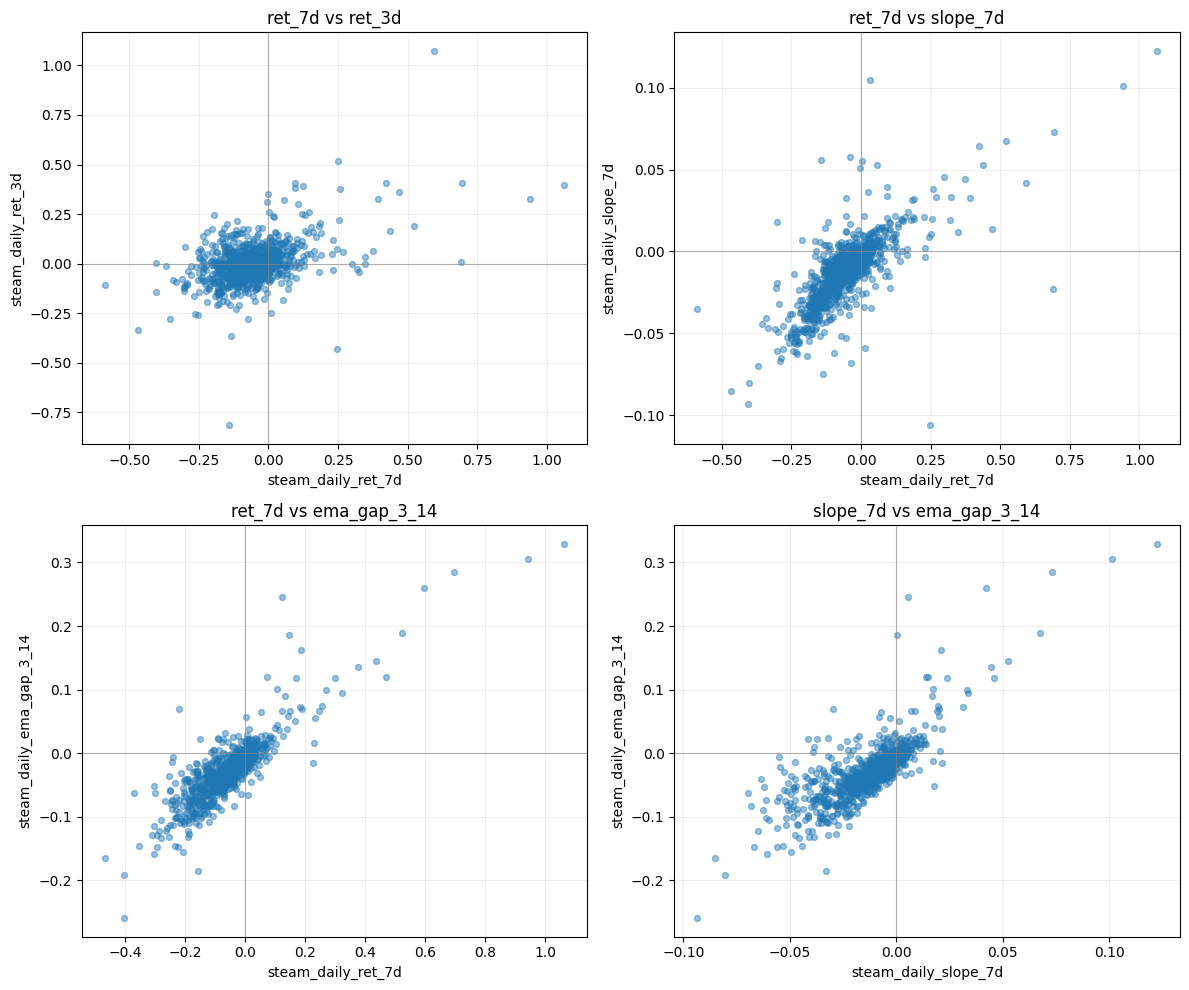

In [5]:
import matplotlib.pyplot as plt

plot_df = df.copy()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].scatter(plot_df['steam_daily_ret_7d'], plot_df['steam_daily_ret_3d'], s=18, alpha=0.45)
axes[0, 0].set_title('ret_7d vs ret_3d')
axes[0, 0].set_xlabel('steam_daily_ret_7d')
axes[0, 0].set_ylabel('steam_daily_ret_3d')

axes[0, 1].scatter(plot_df['steam_daily_ret_7d'], plot_df['steam_daily_slope_7d'], s=18, alpha=0.45)
axes[0, 1].set_title('ret_7d vs slope_7d')
axes[0, 1].set_xlabel('steam_daily_ret_7d')
axes[0, 1].set_ylabel('steam_daily_slope_7d')

axes[1, 0].scatter(plot_df['steam_daily_ret_7d'], plot_df['steam_daily_ema_gap_3_14'], s=18, alpha=0.45)
axes[1, 0].set_title('ret_7d vs ema_gap_3_14')
axes[1, 0].set_xlabel('steam_daily_ret_7d')
axes[1, 0].set_ylabel('steam_daily_ema_gap_3_14')

axes[1, 1].scatter(plot_df['steam_daily_slope_7d'], plot_df['steam_daily_ema_gap_3_14'], s=18, alpha=0.45)
axes[1, 1].set_title('slope_7d vs ema_gap_3_14')
axes[1, 1].set_xlabel('steam_daily_slope_7d')
axes[1, 1].set_ylabel('steam_daily_ema_gap_3_14')

for ax in axes.flat:
    ax.axhline(0, color='gray', linewidth=0.8, alpha=0.6)
    ax.axvline(0, color='gray', linewidth=0.8, alpha=0.6)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()


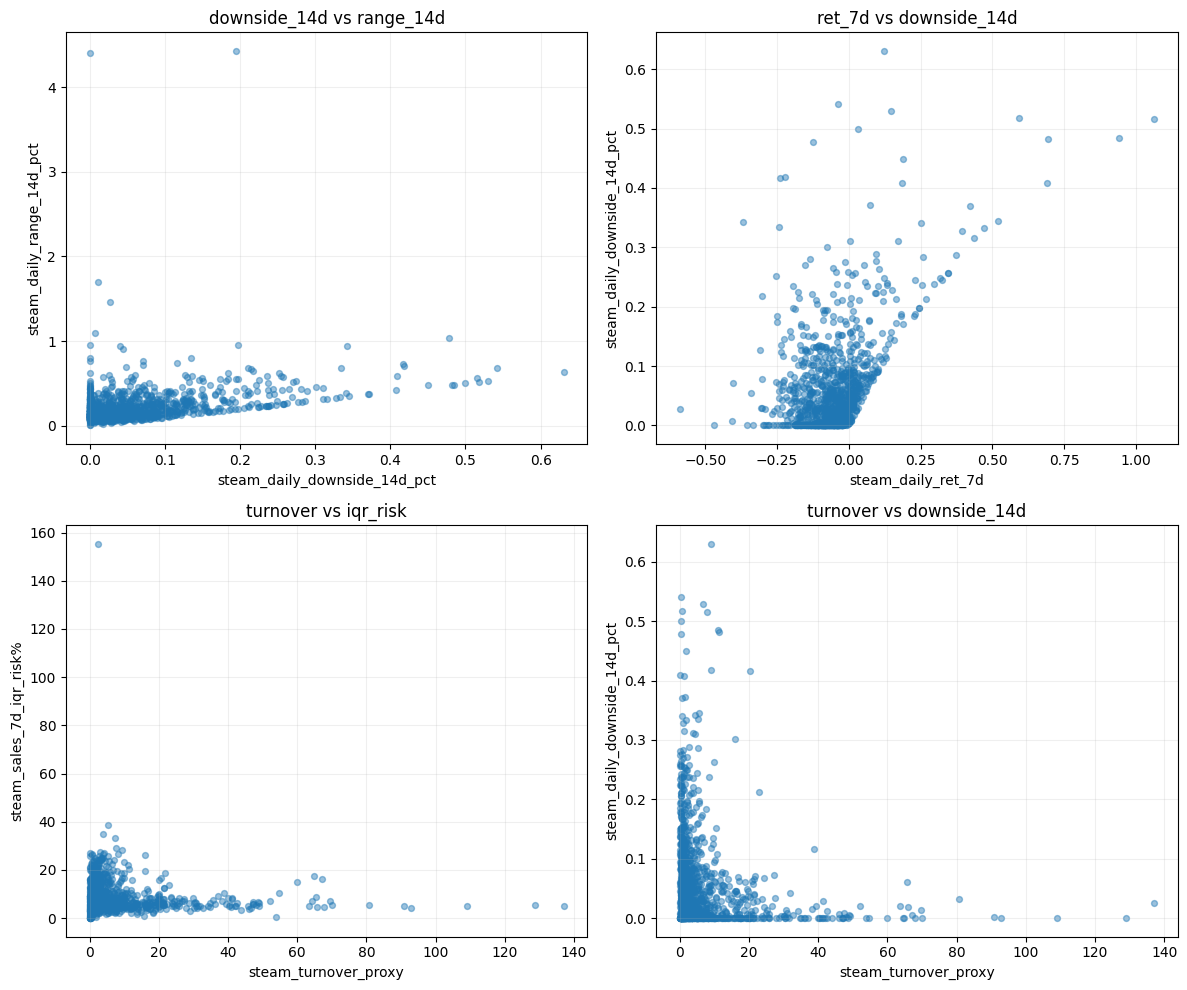

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].scatter(plot_df['steam_daily_downside_14d_pct'], plot_df['steam_daily_range_14d_pct'], s=18, alpha=0.45)
axes[0, 0].set_title('downside_14d vs range_14d')
axes[0, 0].set_xlabel('steam_daily_downside_14d_pct')
axes[0, 0].set_ylabel('steam_daily_range_14d_pct')

axes[0, 1].scatter(plot_df['steam_daily_ret_7d'], plot_df['steam_daily_downside_14d_pct'], s=18, alpha=0.45)
axes[0, 1].set_title('ret_7d vs downside_14d')
axes[0, 1].set_xlabel('steam_daily_ret_7d')
axes[0, 1].set_ylabel('steam_daily_downside_14d_pct')

axes[1, 0].scatter(plot_df['steam_turnover_proxy'], plot_df['steam_sales_7d_iqr_risk%'], s=18, alpha=0.45)
axes[1, 0].set_title('turnover vs iqr_risk')
axes[1, 0].set_xlabel('steam_turnover_proxy')
axes[1, 0].set_ylabel('steam_sales_7d_iqr_risk%')

axes[1, 1].scatter(plot_df['steam_turnover_proxy'], plot_df['steam_daily_downside_14d_pct'], s=18, alpha=0.45)
axes[1, 1].set_title('turnover vs downside_14d')
axes[1, 1].set_xlabel('steam_turnover_proxy')
axes[1, 1].set_ylabel('steam_daily_downside_14d_pct')

for ax in axes.flat:
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()


In [7]:
from pathlib import Path

REPO = Path.cwd()
if not (REPO / 'skin_homog' / 'screener_preprocess_risk' / 'risk_metrics.csv').exists():
    REPO = Path('C:/Roman/skins_roundtrip_v1')

OUTPUT_LIST = REPO / 'lists' / 'skins_normal_filtered2.py'

mask_trend = (
    (
        (df['steam_daily_ret_7d'] >= -0.03)
    )
)

mask_price_risk = (
    (df['steam_daily_downside_14d_pct'] <= 0.17)
)

mask_liquidity = (
    (df['steam_sales_7d_n'] >= 21)
)

mask_listings = (
    (df['n_listings'] >= 20)
)

mask_tail = (
    (df['steam_sales_7d_tail_ratio'] >= 0.85)
)

combo_mask = mask_trend & mask_price_risk & mask_liquidity & mask_tail & mask_listings

combo = df.loc[combo_mask].copy()
combo = combo.sort_values(
    [
        'median_discount',
        'steam_turnover_proxy',
        'steam_daily_ret_7d',
        'steam_daily_slope_7d',
        'steam_daily_downside_14d_pct',
        'steam_sales_7d_iqr_risk%',
    ],
    ascending=[False, False, False, False, True, True],
).reset_index(drop=True)

print(f'combo kept {len(combo)} / {len(df)} items')
print('mask_trend:', int(mask_trend.sum()))
print('mask_price_risk:', int(mask_price_risk.sum()))
print('mask_liquidity:', int(mask_liquidity.sum()))
print('mask_tail:', int(mask_tail.sum()))

items = combo['item'].dropna().astype(str).tolist()
header_lines = [
    '# Auto-generated from risk analysis notebook',
    f'# SOURCE_CSV = {str(INPUT_CSV)!r}',
    f'# OUTPUT_LIST = {str(OUTPUT_LIST)!r}',
    '# mask_ema: ema_gap>=-0.01 & slope>=-0.002 OR (ema is null & ret_7d>=0.01 & slope>=0.0)',
    '# mask_trend: ret_7d>=-0.02 & slope>=-0.003 OR ret_7d>=0.01 & slope>=-0.005',
    '# mask_price_risk: downside_14d<=0.12 OR (downside_14d<=0.18 & range_14d<=0.22)',
    '# mask_liquidity: steam_sales_7d_n>=40 & steam_turnover_proxy>=0.9',
    '# mask_tail: tail_ratio>=0.90 OR (tail_ratio>=0.88 & downside_risk<=8)',
    f'# N_OUTPUT_ITEMS = {len(items)}',
    '',
    'ITEMS = [',
]
body_lines = [f'    {item!r},' for item in items]
text = '\n'.join(header_lines + body_lines + [']', ''])
OUTPUT_LIST.write_text(text, encoding='utf-8')
print(f'saved list to {OUTPUT_LIST}')

combo_show_cols = [c for c in [
    'item', 'base_price', 'n_listings', 'avg_discount', 'median_discount',
    'steam_sales_7d_n', 'steam_sales_7d_iqr_risk%', 'steam_sales_7d_downside_risk%',
    'steam_sales_7d_tail_ratio', 'steam_turnover_proxy',
    'steam_daily_ret_7d', 'steam_daily_slope_7d', 'steam_daily_ema_gap_3_14',
    'steam_daily_range_14d_pct', 'steam_daily_downside_14d_pct',
    'steam_discount_risk_score',
] if c in combo.columns]

display(combo[combo_show_cols].head(10))


combo kept 265 / 1124 items
mask_trend: 385
mask_price_risk: 1018
mask_liquidity: 958
mask_tail: 1051
saved list to C:\Roman\skins_roundtrip_v1\lists\skins_normal_filtered2.py


,item,base_price,n_listings,avg_discount,median_discount,steam_sales_7d_n,steam_sales_7d_iqr_risk%,steam_sales_7d_downside_risk%,steam_sales_7d_tail_ratio,steam_turnover_proxy,steam_daily_ret_7d,steam_daily_slope_7d,steam_daily_ema_gap_3_14,steam_daily_range_14d_pct,steam_daily_downside_14d_pct,steam_discount_risk_score
0,Desert Eagle | Calligraffiti (Factory New),16.21,50,0.205737,0.197837,148,9.019764,7.571296,0.925362,2.96,0.008665,-0.005747,0.011870,0.108190,0.079554,0.141977
1,Galil AR | Black Sand (Factory New),22.76,50,0.186556,0.182922,80,10.405934,4.137744,0.957757,1.60,0.005961,-0.008104,0.029462,0.176741,0.155521,0.153478
2,P2000 | Urban Hazard (Factory New),6.72,50,0.152997,0.150744,91,13.072226,6.485543,0.933307,1.82,-0.021144,-0.027549,-0.017248,0.204791,0.055663,0.097147
3,SSG 08 | Ghost Crusader (Factory New),27.21,50,0.143169,0.138480,53,5.714023,2.567170,0.974214,1.06,0.018206,-0.004309,0.022055,0.096032,0.089227,0.123774
4,AK-47 | Head Shot (Field-Tested),38.20,50,0.104599,0.105423,732,5.628991,5.637831,0.943443,14.64,-0.004130,-0.002819,-0.014544,0.083541,0.024332,0.072106
5,XM1014 | Entombed (Minimal Wear),4.59,50,0.108029,0.104096,844,11.124538,7.979102,0.920699,16.88,0.020495,0.005471,-0.000336,0.131331,0.068634,0.053285
6,AUG | Syd Mead (Field-Tested),11.86,50,0.110092,0.097040,252,4.592722,5.057949,0.949665,5.04,0.008221,-0.003231,-0.006199,0.090863,0.049217,0.075133
7,AK-47 | Nightwish (Battle-Scarred),68.49,50,0.109934,0.086678,326,5.416414,4.666178,0.953390,6.52,0.013464,-0.003095,-0.002338,0.109680,0.047082,0.080797
8,P2000 | Imperial Dragon (Field-Tested),11.81,50,0.070279,0.071528,185,5.904682,5.449178,0.945767,3.70,0.004149,-0.002894,-0.008980,0.085428,0.048585,0.029229
9,Negev | dev_texture (Factory New),3.80,50,0.067385,0.068824,161,15.599663,10.529773,0.894704,3.22,-0.016410,-0.031946,-0.004439,0.281491,0.088792,-0.025406
